# Fase 1 y 2: Tarea 3 y 4 Machine Learning II

## Autores
| Nombres | Correos | 
|----------|----------|
| Julio Lucero   | julio.lucero@alumnos.upm.es  | 
| Rocio Marquez   | rocio.marquez@alumnos.upm.es  | 
|  x | x | 


## Importamos Librerias

In [18]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Model selection y evaluación
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Pipelines y preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Feature selection / importancia
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, f_classif
from sklearn.inspection import permutation_importance

# Naive Bayes
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.preprocessing import KBinsDiscretizer

# Discriminant Analysis
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

# Ensembles
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

# Otros clasificadores útiles para stacking/meta-models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Configuración global
RANDOM_STATE = 42

warnings.filterwarnings("ignore")

## Carga de los datos y Exploracion

In [13]:
TRAIN_FILENAME = "train.csv"
TEST_FILENAME = "test-unlabelled.csv"


def find_file(filename):
    """
    Busca un archivo en rutas habituales:
    - carpeta actual
    - /content, útil en Google Colab
    - /mnt/data, útil en entorno de ChatGPT
    """
    possible_paths = [
        Path(filename),
        Path("/content") / filename,
        Path("/mnt/data") / filename
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"No se encontró {filename}. Asegúrate de que esté en la misma carpeta que el notebook."
    )


train_path = find_file(TRAIN_FILENAME)
test_path = find_file(TEST_FILENAME)

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Archivo train usado: {train_path}")
print(f"Archivo test usado: {test_path}")
print(f"Dimensiones del dataset de entrenamiento: {train_df.shape}")
print(f"Dimensiones del dataset de prueba: {test_df.shape}")

TARGET_COL = "class"

if TARGET_COL not in train_df.columns:
    raise ValueError(f"El dataset de entrenamiento debe contener la columna '{TARGET_COL}'.")

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X = X_train
y = y_train

if TARGET_COL in test_df.columns:
    X_test_final = test_df.drop(columns=[TARGET_COL])
else:
    X_test_final = test_df.copy()

print("\nDimensiones finales:")
print(f"X_train / X: {X.shape}")
print(f"y_train / y: {y.shape}")
print(f"X_test_final: {X_test_final.shape}")

print("\nDistribución de clases en train:")
display(y.value_counts().to_frame("count"))

print("\nProporción de clases:")
display(y.value_counts(normalize=True).to_frame("proportion"))

print("\nValores nulos:")
print(f"Train total nulls: {train_df.isna().sum().sum()}")
print(f"X_train total nulls: {X_train.isna().sum().sum()}")
print(f"Test total nulls: {test_df.isna().sum().sum()}")

if TARGET_COL in test_df.columns:
    print(f"Nulls en test['class']: {test_df[TARGET_COL].isna().sum()}")

Archivo train usado: train.csv
Archivo test usado: test-unlabelled.csv
Dimensiones del dataset de entrenamiento: (1000, 610)
Dimensiones del dataset de prueba: (2000, 610)

Dimensiones finales:
X_train / X: (1000, 609)
y_train / y: (1000,)
X_test_final: (2000, 609)

Distribución de clases en train:


,count
class,
A,347
B,328
C,325



Proporción de clases:


,proportion
class,
A,0.347
B,0.328
C,0.325



Valores nulos:
Train total nulls: 0
X_train total nulls: 0
Test total nulls: 2000
Nulls en test['class']: 2000


In [14]:
# ============================================================
# Evaluación común para todos los modelos
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = []


def evaluate_model(name, model, notes="", X_data=None, y_data=None):
    """
    Evalúa un modelo con:
    - Accuracy en entrenamiento
    - Accuracy media con 5-fold cross-validation

    Guarda el resultado en la lista global results.
    """

    if X_data is None:
        X_data = X

    if y_data is None:
        y_data = y

    model.fit(X_data, y_data)
    train_predictions = model.predict(X_data)
    train_accuracy = accuracy_score(y_data, train_predictions)

    cv_scores = cross_val_score(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    row = {
        "experiment": name,
        "train_accuracy": train_accuracy,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "notes": notes
    }

    results.append(row)

    print(f"Experimento: {name}")
    print(f"Train accuracy: {train_accuracy:.4f}")
    print(f"5-fold CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Notas: {notes}")

    return model, cv_scores

## Preprocesamos, escalamos estandarizando los datos y aplicamos Wrapper para naive bayes

In [15]:
# Definimos el estimador base para Naive Bayes
gnb = GaussianNB()

sfs = SequentialFeatureSelector(gnb, n_features_to_select=20, direction='forward', cv=5, n_jobs=-1)

naive_bayes_wrapper_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', sfs), 
    ('classifier', gnb)
])

# PIPELINE RANDOM FOREST (Lo mantenemos igual, no necesita wrapper)
random_forest_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

## Entrenamiento con Naive Bayes

In [19]:
# Entrenamos el pipeline completo
naive_bayes_wrapper_pipeline.fit(X_train, y_train)

# Calculamos 5-fold Cross Validation con el pipeline
nb_cv_scores = cross_val_score(naive_bayes_wrapper_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Calculamos la precisión en entrenamiento
nb_train_acc = accuracy_score(y_train, naive_bayes_wrapper_pipeline.predict(X_train))

## Resultado de Naive Bayes con wrapper

In [21]:
# Extraemos qué características sobrevivieron al Wrapper
features_seleccionadas = naive_bayes_wrapper_pipeline.named_steps['feature_selection'].get_support()
n_features_elegidas = features_seleccionadas.sum()
columnas_elegidas = X_train.columns[features_seleccionadas].tolist()

print(f"Precisión en Entrenamiento (Train Accuracy): {nb_train_acc:.4f}")
print(f"Precisión 5-Fold CV: {nb_cv_scores.mean():.4f} (+/- {nb_cv_scores.std() * 2:.4f})")
print(f"\nEl Wrapper redujo de {X_train.shape[1]} a {n_features_elegidas} características.")
print(f"Variables conservadas: {columnas_elegidas}") # Descomenta esto si quieres ver los nombres exactos en pantalla

Precisión en Entrenamiento (Train Accuracy): 0.6970
Precisión 5-Fold CV: 0.6540 (+/- 0.0637)

El Wrapper redujo de 609 a 20 características.
Variables conservadas: ['jvbioam', 'ylcgdnd', 'kuzsfrc', 'egshhmq', 'ltpbwwt', 'yanyfsa', 'eadsvll', 'sriualw', 'tsxajlt', 'cacwddh', 'wawgdcs', 'ycyyjjd', 'biorynj', 'gztxoti', 'jafsbde', 'mmocwnw', 'jcpenza', 'bnpymuf', 'rdnxplm', 'tuobnus']


## Naive Bayes con StandardScaler + GaussianNB

In [ ]:
nb_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", GaussianNB())
])

model_nb_scaled, scores_nb_scaled = evaluate_model(
    name="NB-02 StandardScaler + GaussianNB",
    model=nb_scaled,
    notes="Prueba de escalado. Se prueba para comprobar si normalizar las variables afecta al rendimiento de GaussianNB."
)

Experimento: NB-02 StandardScaler + GaussianNB
Train accuracy: 0.6190
5-fold CV accuracy: 0.5390 (+/- 0.0377)
Notas: Prueba de escalado. Se prueba para comprobar si normalizar las variables afecta al rendimiento de GaussianNB.


In [ ]:
pd.DataFrame(results)

,experiment,train_accuracy,cv_mean,cv_std,notes
0,NB-01 GaussianNB baseline,0.619,0.539,0.037736,Baseline sin preprocesamiento. Sirve para medi...
1,NB-02 StandardScaler + GaussianNB,0.619,0.539,0.037736,Prueba de escalado. Se prueba para comprobar s...


## GaussianNB con selección de variables

In [ ]:
k_values = [5, 10, 20, 40, 60, 100, 200, 300]

nb_kbest_models = {}

for k in k_values:
    nb_kbest = Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("classifier", GaussianNB())
    ])
    
    model, scores = evaluate_model(
        name=f"NB-03 SelectKBest k={k} + GaussianNB",
        model=nb_kbest,
        notes=f"Selección de las {k} variables más relacionadas individualmente con la clase mediante ANOVA F-test."
    )
    
    nb_kbest_models[k] = {
        "model": model,
        "scores": scores
    }

Experimento: NB-03 SelectKBest k=5 + GaussianNB
Train accuracy: 0.6250
5-fold CV accuracy: 0.6210 (+/- 0.0285)
Notas: Selección de las 5 variables más relacionadas individualmente con la clase mediante ANOVA F-test.
Experimento: NB-03 SelectKBest k=10 + GaussianNB
Train accuracy: 0.6410
5-fold CV accuracy: 0.6420 (+/- 0.0211)
Notas: Selección de las 10 variables más relacionadas individualmente con la clase mediante ANOVA F-test.
Experimento: NB-03 SelectKBest k=20 + GaussianNB
Train accuracy: 0.6260
5-fold CV accuracy: 0.6380 (+/- 0.0196)
Notas: Selección de las 20 variables más relacionadas individualmente con la clase mediante ANOVA F-test.
Experimento: NB-03 SelectKBest k=40 + GaussianNB
Train accuracy: 0.6110
5-fold CV accuracy: 0.6150 (+/- 0.0228)
Notas: Selección de las 40 variables más relacionadas individualmente con la clase mediante ANOVA F-test.
Experimento: NB-03 SelectKBest k=60 + GaussianNB
Train accuracy: 0.5870
5-fold CV accuracy: 0.5950 (+/- 0.0152)
Notas: Selección d

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values("cv_mean", ascending=False)

,experiment,train_accuracy,cv_mean,cv_std,notes
3,NB-03 SelectKBest k=10 + GaussianNB,0.641,0.642,0.021119,Selección de las 10 variables más relacionadas...
4,NB-03 SelectKBest k=20 + GaussianNB,0.626,0.638,0.019647,Selección de las 20 variables más relacionadas...
2,NB-03 SelectKBest k=5 + GaussianNB,0.625,0.621,0.028531,Selección de las 5 variables más relacionadas ...
5,NB-03 SelectKBest k=40 + GaussianNB,0.611,0.615,0.022804,Selección de las 40 variables más relacionadas...
6,NB-03 SelectKBest k=60 + GaussianNB,0.587,0.595,0.015166,Selección de las 60 variables más relacionadas...
7,NB-03 SelectKBest k=100 + GaussianNB,0.571,0.580,0.018166,Selección de las 100 variables más relacionada...
8,NB-03 SelectKBest k=200 + GaussianNB,0.585,0.566,0.022450,Selección de las 200 variables más relacionada...
9,NB-03 SelectKBest k=300 + GaussianNB,0.591,0.559,0.023537,Selección de las 300 variables más relacionada...
0,NB-01 GaussianNB baseline,0.619,0.539,0.037736,Baseline sin preprocesamiento. Sirve para medi...
1,NB-02 StandardScaler + GaussianNB,0.619,0.539,0.037736,Prueba de escalado. Se prueba para comprobar s...


In [ ]:
k_values_fine = [6, 8, 10, 12, 15, 18, 20, 25, 30]

nb_kbest_fine_models = {}

for k in k_values_fine:
    nb_kbest = Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=k)),
        ("classifier", GaussianNB())
    ])
    
    model, scores = evaluate_model(
        name=f"NB-04 Fine SelectKBest k={k} + GaussianNB",
        model=nb_kbest,
        notes=f"Ajuste fino de selección de variables alrededor del mejor valor previo. k={k}."
    )
    
    nb_kbest_fine_models[k] = {
        "model": model,
        "scores": scores
    }

Experimento: NB-04 Fine SelectKBest k=6 + GaussianNB
Train accuracy: 0.6220
5-fold CV accuracy: 0.6160 (+/- 0.0357)
Notas: Ajuste fino de selección de variables alrededor del mejor valor previo. k=6.
Experimento: NB-04 Fine SelectKBest k=8 + GaussianNB
Train accuracy: 0.6220
5-fold CV accuracy: 0.6240 (+/- 0.0235)
Notas: Ajuste fino de selección de variables alrededor del mejor valor previo. k=8.
Experimento: NB-04 Fine SelectKBest k=10 + GaussianNB
Train accuracy: 0.6410
5-fold CV accuracy: 0.6420 (+/- 0.0211)
Notas: Ajuste fino de selección de variables alrededor del mejor valor previo. k=10.
Experimento: NB-04 Fine SelectKBest k=12 + GaussianNB
Train accuracy: 0.6400
5-fold CV accuracy: 0.6400 (+/- 0.0235)
Notas: Ajuste fino de selección de variables alrededor del mejor valor previo. k=12.
Experimento: NB-04 Fine SelectKBest k=15 + GaussianNB
Train accuracy: 0.6360
5-fold CV accuracy: 0.6400 (+/- 0.0247)
Notas: Ajuste fino de selección de variables alrededor del mejor valor previo. 

In [ ]:
results_df = pd.DataFrame(results)
results_df.sort_values("cv_mean", ascending=False).head(15)

,experiment,train_accuracy,cv_mean,cv_std,notes
3,NB-03 SelectKBest k=10 + GaussianNB,0.641,0.642,0.021119,Selección de las 10 variables más relacionadas...
12,NB-04 Fine SelectKBest k=10 + GaussianNB,0.641,0.642,0.021119,Ajuste fino de selección de variables alrededo...
13,NB-04 Fine SelectKBest k=12 + GaussianNB,0.640,0.640,0.023452,Ajuste fino de selección de variables alrededo...
14,NB-04 Fine SelectKBest k=15 + GaussianNB,0.636,0.640,0.024698,Ajuste fino de selección de variables alrededo...
16,NB-04 Fine SelectKBest k=20 + GaussianNB,0.626,0.638,0.019647,Ajuste fino de selección de variables alrededo...
4,NB-03 SelectKBest k=20 + GaussianNB,0.626,0.638,0.019647,Selección de las 20 variables más relacionadas...
15,NB-04 Fine SelectKBest k=18 + GaussianNB,0.620,0.637,0.016000,Ajuste fino de selección de variables alrededo...
17,NB-04 Fine SelectKBest k=25 + GaussianNB,0.634,0.635,0.016125,Ajuste fino de selección de variables alrededo...
11,NB-04 Fine SelectKBest k=8 + GaussianNB,0.622,0.624,0.023537,Ajuste fino de selección de variables alrededo...
2,NB-03 SelectKBest k=5 + GaussianNB,0.625,0.621,0.028531,Selección de las 5 variables más relacionadas ...


## SelectKBest + discretización + CategoricalNB

In [20]:
discretization_results = {}

n_bins_values = [3, 5, 10]
strategies = ["uniform", "quantile"]

for n_bins in n_bins_values:
    for strategy in strategies:
        nb_discrete = Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=10)),
            ("discretizer", KBinsDiscretizer(
                n_bins=n_bins,
                encode="ordinal",
                strategy=strategy
            )),
            ("classifier", CategoricalNB(alpha=1.0))
        ])
        
        model, scores = evaluate_model(
            name=f"NB-05 SelectKBest k=10 + KBins {strategy} bins={n_bins} + CategoricalNB",
            model=nb_discrete,
            notes=f"Discretización de las 10 mejores variables con {n_bins} bins y estrategia {strategy}, seguida de CategoricalNB."
        )
        
        discretization_results[(n_bins, strategy)] = {
            "model": model,
            "scores": scores
        }

Experimento: NB-05 SelectKBest k=10 + KBins uniform bins=3 + CategoricalNB
Train accuracy: 0.4010
5-fold CV accuracy: 0.4940 (+/- 0.0859)
Notas: Discretización de las 10 mejores variables con 3 bins y estrategia uniform, seguida de CategoricalNB.
Experimento: NB-05 SelectKBest k=10 + KBins quantile bins=3 + CategoricalNB
Train accuracy: 0.7500
5-fold CV accuracy: 0.7420 (+/- 0.0204)
Notas: Discretización de las 10 mejores variables con 3 bins y estrategia quantile, seguida de CategoricalNB.
Experimento: NB-05 SelectKBest k=10 + KBins uniform bins=5 + CategoricalNB
Train accuracy: 0.7370
5-fold CV accuracy: 0.7220 (+/- 0.0238)
Notas: Discretización de las 10 mejores variables con 5 bins y estrategia uniform, seguida de CategoricalNB.
Experimento: NB-05 SelectKBest k=10 + KBins quantile bins=5 + CategoricalNB
Train accuracy: 0.7730
5-fold CV accuracy: 0.7650 (+/- 0.0362)
Notas: Discretización de las 10 mejores variables con 5 bins y estrategia quantile, seguida de CategoricalNB.
Experime

In [22]:
results_df = pd.DataFrame(results)
results_df.sort_values("cv_mean", ascending=False).head(20)

,experiment,train_accuracy,cv_mean,cv_std,notes
5,NB-05 SelectKBest k=10 + KBins quantile bins=1...,0.794,0.771,0.022000,Discretización de las 10 mejores variables con...
3,NB-05 SelectKBest k=10 + KBins quantile bins=5...,0.773,0.765,0.036194,Discretización de las 10 mejores variables con...
1,NB-05 SelectKBest k=10 + KBins quantile bins=3...,0.750,0.742,0.020396,Discretización de las 10 mejores variables con...
4,NB-05 SelectKBest k=10 + KBins uniform bins=10...,0.761,0.741,0.022000,Discretización de las 10 mejores variables con...
2,NB-05 SelectKBest k=10 + KBins uniform bins=5 ...,0.737,0.722,0.023791,Discretización de las 10 mejores variables con...
0,NB-05 SelectKBest k=10 + KBins uniform bins=3 ...,0.401,0.494,0.085872,Discretización de las 10 mejores variables con...


In [23]:
k_values_cat = [8, 10, 12, 15, 20]
n_bins_values_cat = [5, 8, 10, 12, 15, 20]

cat_tuning_results = {}

for k in k_values_cat:
    for n_bins in n_bins_values_cat:
        nb_cat = Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=k)),
            ("discretizer", KBinsDiscretizer(
                n_bins=n_bins,
                encode="ordinal",
                strategy="quantile"
            )),
            ("classifier", CategoricalNB(alpha=1.0))
        ])
        
        model, scores = evaluate_model(
            name=f"NB-06 SelectKBest k={k} + quantile bins={n_bins} + CategoricalNB",
            model=nb_cat,
            notes=f"Ajuste de CategoricalNB con selección de {k} variables y discretización quantile con {n_bins} bins."
        )
        
        cat_tuning_results[(k, n_bins)] = {
            "model": model,
            "scores": scores
        }

Experimento: NB-06 SelectKBest k=8 + quantile bins=5 + CategoricalNB
Train accuracy: 0.7570
5-fold CV accuracy: 0.7480 (+/- 0.0333)
Notas: Ajuste de CategoricalNB con selección de 8 variables y discretización quantile con 5 bins.
Experimento: NB-06 SelectKBest k=8 + quantile bins=8 + CategoricalNB
Train accuracy: 0.7750
5-fold CV accuracy: 0.7580 (+/- 0.0172)
Notas: Ajuste de CategoricalNB con selección de 8 variables y discretización quantile con 8 bins.
Experimento: NB-06 SelectKBest k=8 + quantile bins=10 + CategoricalNB
Train accuracy: 0.7840
5-fold CV accuracy: 0.7560 (+/- 0.0174)
Notas: Ajuste de CategoricalNB con selección de 8 variables y discretización quantile con 10 bins.
Experimento: NB-06 SelectKBest k=8 + quantile bins=12 + CategoricalNB
Train accuracy: 0.7820
5-fold CV accuracy: 0.7590 (+/- 0.0169)
Notas: Ajuste de CategoricalNB con selección de 8 variables y discretización quantile con 12 bins.
Experimento: NB-06 SelectKBest k=8 + quantile bins=15 + CategoricalNB
Train 

In [24]:
results_df = pd.DataFrame(results)
results_df.sort_values("cv_mean", ascending=False).head(25)

,experiment,train_accuracy,cv_mean,cv_std,notes
33,NB-06 SelectKBest k=20 + quantile bins=12 + Ca...,0.816,0.795,0.008944,Ajuste de CategoricalNB con selección de 20 va...
32,NB-06 SelectKBest k=20 + quantile bins=10 + Ca...,0.797,0.787,0.014353,Ajuste de CategoricalNB con selección de 20 va...
31,NB-06 SelectKBest k=20 + quantile bins=8 + Cat...,0.800,0.783,0.009274,Ajuste de CategoricalNB con selección de 20 va...
35,NB-06 SelectKBest k=20 + quantile bins=20 + Ca...,0.833,0.782,0.024207,Ajuste de CategoricalNB con selección de 20 va...
34,NB-06 SelectKBest k=20 + quantile bins=15 + Ca...,0.821,0.781,0.017146,Ajuste de CategoricalNB con selección de 20 va...
16,NB-06 SelectKBest k=10 + quantile bins=15 + Ca...,0.802,0.776,0.029394,Ajuste de CategoricalNB con selección de 10 va...
22,NB-06 SelectKBest k=12 + quantile bins=15 + Ca...,0.808,0.776,0.020347,Ajuste de CategoricalNB con selección de 12 va...
20,NB-06 SelectKBest k=12 + quantile bins=10 + Ca...,0.803,0.776,0.022226,Ajuste de CategoricalNB con selección de 12 va...
30,NB-06 SelectKBest k=20 + quantile bins=5 + Cat...,0.779,0.775,0.016125,Ajuste de CategoricalNB con selección de 20 va...
19,NB-06 SelectKBest k=12 + quantile bins=8 + Cat...,0.791,0.774,0.030232,Ajuste de CategoricalNB con selección de 12 va...


## Expandir seleccion de variables

In [25]:
k_values_cat_expanded = [20, 25, 30, 40, 60]
n_bins_values_cat_expanded = [8, 10, 12, 15]

cat_expanded_results = {}

for k in k_values_cat_expanded:
    for n_bins in n_bins_values_cat_expanded:
        nb_cat = Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=k)),
            ("discretizer", KBinsDiscretizer(
                n_bins=n_bins,
                encode="ordinal",
                strategy="quantile"
            )),
            ("classifier", CategoricalNB(alpha=1.0))
        ])
        
        model, scores = evaluate_model(
            name=f"NB-07 Expanded SelectKBest k={k} + quantile bins={n_bins} + CategoricalNB",
            model=nb_cat,
            notes=f"Ampliación de búsqueda para CategoricalNB: {k} variables y {n_bins} bins quantile."
        )
        
        cat_expanded_results[(k, n_bins)] = {
            "model": model,
            "scores": scores
        }

Experimento: NB-07 Expanded SelectKBest k=20 + quantile bins=8 + CategoricalNB
Train accuracy: 0.8000
5-fold CV accuracy: 0.7830 (+/- 0.0093)
Notas: Ampliación de búsqueda para CategoricalNB: 20 variables y 8 bins quantile.
Experimento: NB-07 Expanded SelectKBest k=20 + quantile bins=10 + CategoricalNB
Train accuracy: 0.7970
5-fold CV accuracy: 0.7870 (+/- 0.0144)
Notas: Ampliación de búsqueda para CategoricalNB: 20 variables y 10 bins quantile.
Experimento: NB-07 Expanded SelectKBest k=20 + quantile bins=12 + CategoricalNB
Train accuracy: 0.8160
5-fold CV accuracy: 0.7950 (+/- 0.0089)
Notas: Ampliación de búsqueda para CategoricalNB: 20 variables y 12 bins quantile.
Experimento: NB-07 Expanded SelectKBest k=20 + quantile bins=15 + CategoricalNB
Train accuracy: 0.8210
5-fold CV accuracy: 0.7810 (+/- 0.0171)
Notas: Ampliación de búsqueda para CategoricalNB: 20 variables y 15 bins quantile.
Experimento: NB-07 Expanded SelectKBest k=25 + quantile bins=8 + CategoricalNB
Train accuracy: 0.8

In [26]:
results_df = pd.DataFrame(results)
results_df.sort_values("cv_mean", ascending=False).head(30)

,experiment,train_accuracy,cv_mean,cv_std,notes
55,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.859,0.805,0.013416,Ampliación de búsqueda para CategoricalNB: 60 ...
53,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.843,0.803,0.015684,Ampliación de búsqueda para CategoricalNB: 60 ...
54,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.849,0.801,0.007348,Ampliación de búsqueda para CategoricalNB: 60 ...
52,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.839,0.800,0.006325,Ampliación de búsqueda para CategoricalNB: 60 ...
40,NB-07 Expanded SelectKBest k=25 + quantile bin...,0.815,0.799,0.016852,Ampliación de búsqueda para CategoricalNB: 25 ...
51,NB-07 Expanded SelectKBest k=40 + quantile bin...,0.843,0.797,0.014697,Ampliación de búsqueda para CategoricalNB: 40 ...
33,NB-06 SelectKBest k=20 + quantile bins=12 + Ca...,0.816,0.795,0.008944,Ajuste de CategoricalNB con selección de 20 va...
38,NB-07 Expanded SelectKBest k=20 + quantile bin...,0.816,0.795,0.008944,Ampliación de búsqueda para CategoricalNB: 20 ...
43,NB-07 Expanded SelectKBest k=25 + quantile bin...,0.828,0.795,0.021213,Ampliación de búsqueda para CategoricalNB: 25 ...
45,NB-07 Expanded SelectKBest k=30 + quantile bin...,0.827,0.794,0.017436,Ampliación de búsqueda para CategoricalNB: 30 ...


In [27]:
k_values_cat_boundary = [60, 80, 100, 150]
n_bins_values_cat_boundary = [10, 12, 15, 20]

cat_boundary_results = {}

for k in k_values_cat_boundary:
    for n_bins in n_bins_values_cat_boundary:
        nb_cat = Pipeline([
            ("select", SelectKBest(score_func=f_classif, k=k)),
            ("discretizer", KBinsDiscretizer(
                n_bins=n_bins,
                encode="ordinal",
                strategy="quantile"
            )),
            ("classifier", CategoricalNB(alpha=1.0))
        ])
        
        model, scores = evaluate_model(
            name=f"NB-08 Boundary SelectKBest k={k} + quantile bins={n_bins} + CategoricalNB",
            model=nb_cat,
            notes=f"Comprobación del límite de variables para CategoricalNB: {k} variables y {n_bins} bins quantile."
        )
        
        cat_boundary_results[(k, n_bins)] = {
            "model": model,
            "scores": scores
        }

Experimento: NB-08 Boundary SelectKBest k=60 + quantile bins=10 + CategoricalNB
Train accuracy: 0.8430
5-fold CV accuracy: 0.8030 (+/- 0.0157)
Notas: Comprobación del límite de variables para CategoricalNB: 60 variables y 10 bins quantile.
Experimento: NB-08 Boundary SelectKBest k=60 + quantile bins=12 + CategoricalNB
Train accuracy: 0.8490
5-fold CV accuracy: 0.8010 (+/- 0.0073)
Notas: Comprobación del límite de variables para CategoricalNB: 60 variables y 12 bins quantile.
Experimento: NB-08 Boundary SelectKBest k=60 + quantile bins=15 + CategoricalNB
Train accuracy: 0.8590
5-fold CV accuracy: 0.8050 (+/- 0.0134)
Notas: Comprobación del límite de variables para CategoricalNB: 60 variables y 15 bins quantile.
Experimento: NB-08 Boundary SelectKBest k=60 + quantile bins=20 + CategoricalNB
Train accuracy: 0.8700
5-fold CV accuracy: 0.8010 (+/- 0.0146)
Notas: Comprobación del límite de variables para CategoricalNB: 60 variables y 20 bins quantile.
Experimento: NB-08 Boundary SelectKBest 

In [28]:
results_df = pd.DataFrame(results)
results_df.sort_values("cv_mean", ascending=False).head(30)

,experiment,train_accuracy,cv_mean,cv_std,notes
55,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.859,0.805,0.013416,Ampliación de búsqueda para CategoricalNB: 60 ...
58,NB-08 Boundary SelectKBest k=60 + quantile bin...,0.859,0.805,0.013416,Comprobación del límite de variables para Cate...
56,NB-08 Boundary SelectKBest k=60 + quantile bin...,0.843,0.803,0.015684,Comprobación del límite de variables para Cate...
53,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.843,0.803,0.015684,Ampliación de búsqueda para CategoricalNB: 60 ...
60,NB-08 Boundary SelectKBest k=80 + quantile bin...,0.841,0.802,0.009274,Comprobación del límite de variables para Cate...
62,NB-08 Boundary SelectKBest k=80 + quantile bin...,0.851,0.801,0.005831,Comprobación del límite de variables para Cate...
59,NB-08 Boundary SelectKBest k=60 + quantile bin...,0.870,0.801,0.014629,Comprobación del límite de variables para Cate...
54,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.849,0.801,0.007348,Ampliación de búsqueda para CategoricalNB: 60 ...
61,NB-08 Boundary SelectKBest k=80 + quantile bin...,0.852,0.801,0.015297,Comprobación del límite de variables para Cate...
57,NB-08 Boundary SelectKBest k=60 + quantile bin...,0.849,0.801,0.007348,Comprobación del límite de variables para Cate...


## Ajuste de Alfa

In [29]:
alpha_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

alpha_results = {}

for alpha in alpha_values:
    nb_cat_alpha = Pipeline([
        ("select", SelectKBest(score_func=f_classif, k=60)),
        ("discretizer", KBinsDiscretizer(
            n_bins=15,
            encode="ordinal",
            strategy="quantile"
        )),
        ("classifier", CategoricalNB(alpha=alpha))
    ])
    
    model, scores = evaluate_model(
        name=f"NB-09 SelectKBest k=60 + quantile bins=15 + CategoricalNB alpha={alpha}",
        model=nb_cat_alpha,
        notes=f"Ajuste del parámetro de suavizado alpha={alpha} para la mejor configuración de CategoricalNB."
    )
    
    alpha_results[alpha] = {
        "model": model,
        "scores": scores
    }

Experimento: NB-09 SelectKBest k=60 + quantile bins=15 + CategoricalNB alpha=0.01
Train accuracy: 0.8610
5-fold CV accuracy: 0.8110 (+/- 0.0166)
Notas: Ajuste del parámetro de suavizado alpha=0.01 para la mejor configuración de CategoricalNB.
Experimento: NB-09 SelectKBest k=60 + quantile bins=15 + CategoricalNB alpha=0.05
Train accuracy: 0.8610
5-fold CV accuracy: 0.8130 (+/- 0.0163)
Notas: Ajuste del parámetro de suavizado alpha=0.05 para la mejor configuración de CategoricalNB.
Experimento: NB-09 SelectKBest k=60 + quantile bins=15 + CategoricalNB alpha=0.1
Train accuracy: 0.8600
5-fold CV accuracy: 0.8130 (+/- 0.0163)
Notas: Ajuste del parámetro de suavizado alpha=0.1 para la mejor configuración de CategoricalNB.
Experimento: NB-09 SelectKBest k=60 + quantile bins=15 + CategoricalNB alpha=0.5
Train accuracy: 0.8600
5-fold CV accuracy: 0.8110 (+/- 0.0132)
Notas: Ajuste del parámetro de suavizado alpha=0.5 para la mejor configuración de CategoricalNB.
Experimento: NB-09 SelectKBest k

In [30]:
results_df = pd.DataFrame(results)
results_df.sort_values("cv_mean", ascending=False).head(30)

,experiment,train_accuracy,cv_mean,cv_std,notes
73,NB-09 SelectKBest k=60 + quantile bins=15 + Ca...,0.861,0.813,0.016310,Ajuste del parámetro de suavizado alpha=0.05 p...
74,NB-09 SelectKBest k=60 + quantile bins=15 + Ca...,0.860,0.813,0.016310,Ajuste del parámetro de suavizado alpha=0.1 pa...
72,NB-09 SelectKBest k=60 + quantile bins=15 + Ca...,0.861,0.811,0.016553,Ajuste del parámetro de suavizado alpha=0.01 p...
75,NB-09 SelectKBest k=60 + quantile bins=15 + Ca...,0.860,0.811,0.013191,Ajuste del parámetro de suavizado alpha=0.5 pa...
55,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.859,0.805,0.013416,Ampliación de búsqueda para CategoricalNB: 60 ...
58,NB-08 Boundary SelectKBest k=60 + quantile bin...,0.859,0.805,0.013416,Comprobación del límite de variables para Cate...
76,NB-09 SelectKBest k=60 + quantile bins=15 + Ca...,0.859,0.805,0.013416,Ajuste del parámetro de suavizado alpha=1.0 pa...
53,NB-07 Expanded SelectKBest k=60 + quantile bin...,0.843,0.803,0.015684,Ampliación de búsqueda para CategoricalNB: 60 ...
56,NB-08 Boundary SelectKBest k=60 + quantile bin...,0.843,0.803,0.015684,Comprobación del límite de variables para Cate...
60,NB-08 Boundary SelectKBest k=80 + quantile bin...,0.841,0.802,0.009274,Comprobación del límite de variables para Cate...


## Entrenamiento con Random Forest

In [ ]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],        
    'classifier__max_depth': [5, 8, 12, 15],             
    'classifier__min_samples_split': [5, 10, 20],        
    'classifier__min_samples_leaf': [2, 5, 10],          
    'classifier__max_features': ['sqrt', 0.5]            
}

random_forest_grid = GridSearchCV(random_forest_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
random_forest_grid.fit(X_train, y_train)

best_rf = random_forest_grid.best_estimator_
rf_train_acc = accuracy_score(y_train, best_rf.predict(X_train))

print(f"Mejores parámetros encontrados: {random_forest_grid.best_params_}")
print(f"Precisión en Entrenamiento (Train Accuracy): {rf_train_acc:.4f}")
print(f"Precisión 5-Fold CV (Mejor Modelo): {random_forest_grid.best_score_:.4f}")

Mejores parámetros encontrados: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Precisión en Entrenamiento (Train Accuracy): 0.9700
Precisión 5-Fold CV (Mejor Modelo): 0.8270


## Importancia de caracteristicas en Random Forest

     Feature  Importance
98   yanyfsa    0.029518
281  vzyjlbt    0.024946
382  jafsbde    0.024815
236  mwvshcy    0.019883
465  bffqymv    0.018610
134  qmkchdk    0.018278
520  plcvrqv    0.016560
392  qydpedv    0.015686
150  eadsvll    0.015392
50   pmvpzze    0.014939


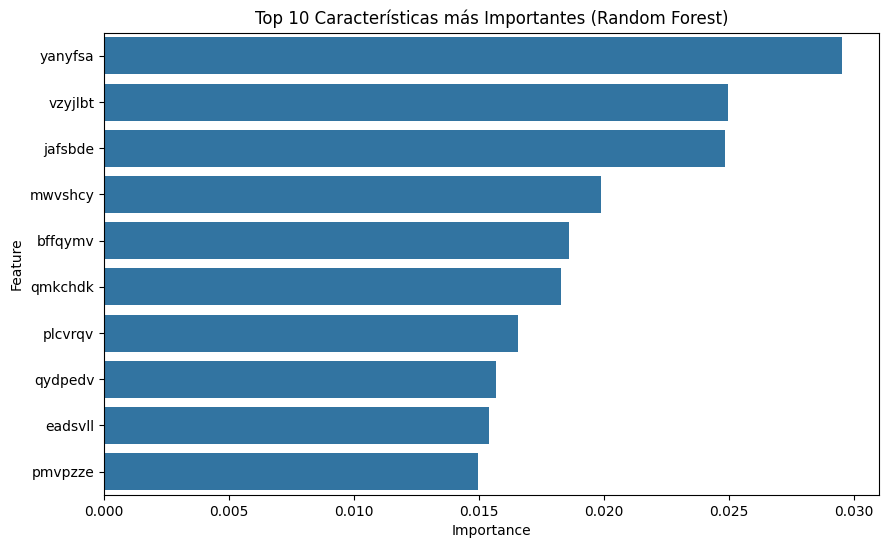

In [ ]:
random_forest_model = best_rf.named_steps['classifier']
importances = random_forest_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10)) 

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Características más Importantes (Random Forest)')
plt.show()

## AdaBoost - Rocio

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

Cargamos datos


In [ ]:
train = pd.read_csv("train.csv")

X = train.drop("class", axis=1)
y = train["class"]

TARGET = "class"
X_train = X
y_train = y
has_val_labels = False  # no hay test set con etiquetas

print(f"Shape: {X.shape}")
print(f"Clases: {y.unique()}")

Shape: (1000, 609)
Clases: ['C' 'B' 'A']


Pipeline

Se construye un pipeline con:
Modelo principal: AdaBoostClassifier
Modelo base: DecisionTreeClassifier
No hay escalado porque no es necesario, se fija random_state para reproducibilidad

In [ ]:
base_pipeline = Pipeline([
    ("classifier",
        AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            algorithm="SAMME",
            random_state=42
        )
    )
])
 

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Se definen combinaciones de hiperparámetros:

n_estimators: número de modelos débiles.
learning_rate: controla contribución de cada árbol.
max_depth: complejidad del árbol base.
min_samples_leaf/split: regularización.

La idea es encontrar equilibrio entre bias y variance.

In [ ]:
param_grid = {
    "classifier__n_estimators":                [100, 200, 300],
    "classifier__learning_rate":               [0.01, 0.1, 0.5, 1.0],
    "classifier__estimator__max_depth":        [1, 2, 3],
    "classifier__estimator__min_samples_leaf": [1, 5, 10],
    "classifier__estimator__min_samples_split":[2, 10, 20],
}

Se realiza búsqueda de hiperparámetros, evalúa todas las combinaciones del grid, usa validación cruzada.
Métrica: accuracy.
n_jobs=-1: usa todos los cores.
Así logra encontrar el mejor modelo automáticamente.

In [ ]:
grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
 
grid_search.fit(X_train, y_train)
 
print(f"\nMejores parámetros:\n{grid_search.best_params_}")
print(f"Mejor CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


/home/rocimarquez/.local/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/rocimarquez/.local/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/rocimarquez/.local/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/rocimarquez/.local/lib/python3.10/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
/home/rocimarquez/.local/lib/python3.10/site-packages/sklearn/ensemble/_weight_boost


Mejores parámetros:
{'classifier__estimator__max_depth': 3, 'classifier__estimator__min_samples_leaf': 1, 'classifier__estimator__min_samples_split': 2, 'classifier__learning_rate': 1.0, 'classifier__n_estimators': 300}
Mejor CV accuracy: 0.8100


In [ ]:
cv_results = pd.DataFrame(grid_search.cv_results_)
 
summary_cols = {
    "param_classifier__n_estimators":                "n_estimators",
    "param_classifier__learning_rate":               "learning_rate",
    "param_classifier__estimator__max_depth":        "max_depth",
    "param_classifier__estimator__min_samples_leaf": "min_samples_leaf",
    "param_classifier__estimator__min_samples_split":"min_samples_split",
    "mean_train_score":                              "train_accuracy",
    "mean_test_score":                               "cv_accuracy",
    "std_test_score":                                "cv_std",
}
 
results_df = cv_results[list(summary_cols.keys())].rename(columns=summary_cols).copy()
results_df["overfit_gap"] = results_df["train_accuracy"] - results_df["cv_accuracy"]
results_df = results_df.sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
 
print("\n TOP 10 CONFIGURACIONES")
print(results_df.head(10).to_string(index=False))


 TOP 10 CONFIGURACIONES
 n_estimators  learning_rate  max_depth  min_samples_leaf  min_samples_split  train_accuracy  cv_accuracy   cv_std  overfit_gap
          300            1.0          3                 1                  2          1.0000        0.810 0.017607       0.1900
          200            0.1          3                10                  2          0.9975        0.807 0.013638       0.1905
          200            0.1          3                10                 20          0.9975        0.807 0.013638       0.1905
          200            0.1          3                10                 10          0.9975        0.807 0.013638       0.1905
          200            0.5          3                 1                  2          1.0000        0.806 0.025573       0.1940
          300            0.5          3                 1                  2          1.0000        0.806 0.025377       0.1940
          300            1.0          3                 5                 20   

Mejor modelo y evaluación final

In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
 
train_acc  = best_model.score(X_train, y_train)
best_cv    = grid_search.best_score_
overfit    = train_acc - best_cv
 
print("\n--- EVALUACIÓN DEL MEJOR MODELO ---")
print(f"Train accuracy : {train_acc:.4f}")
print(f"CV accuracy    : {best_cv:.4f}")
print(f"Overfit gap    : {overfit:.4f}")
 
print("\nClassification report (train):")
print(classification_report(y_train, best_model.predict(X_train)))


--- EVALUACIÓN DEL MEJOR MODELO ---
Train accuracy : 1.0000
CV accuracy    : 0.8100
Overfit gap    : 0.1900

Classification report (train):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       347
           B       1.00      1.00      1.00       328
           C       1.00      1.00      1.00       325

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Predicciones de probabilidades 

In [ ]:
proba_train = pd.DataFrame(
    best_model.predict_proba(X_train),
    columns=[f"P(class={c})" for c in best_model.classes_]
)
print("\n PROBABILIDADES PREDICHAS") #primeras 5 train test
print(proba_train.head())
 


 PROBABILIDADES PREDICHAS
   P(class=A)  P(class=B)  P(class=C)
0    0.272607    0.354767    0.372627
1    0.288497    0.375253    0.336250
2    0.388102    0.312404    0.299494
3    0.286975    0.328685    0.384339
4    0.283721    0.374248    0.342031


Permutaciones de features

In [ ]:
perm_imp = permutation_importance(
    best_model,
    X_train,
    y_train,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
 
importance_df = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": perm_imp.importances_mean,
    "std":        perm_imp.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)
 
print("\nTOP 15 FEATURES")
print(importance_df.head(15).to_string(index=False))
 


TOP 15 FEATURES
feature  importance      std
yanyfsa      0.0110 0.002449
vzyjlbt      0.0008 0.000748
jboadtj      0.0007 0.000458
qmkchdk      0.0003 0.000458
vazzdmc      0.0000 0.000000
rjfwiln      0.0000 0.000000
drzvzap      0.0000 0.000000
iubfpnz      0.0000 0.000000
keddxuj      0.0000 0.000000
lewegpn      0.0000 0.000000
lnauxax      0.0000 0.000000
pmnsphz      0.0000 0.000000
qlabzmd      0.0000 0.000000
yvbrwwc      0.0000 0.000000
nupyxah      0.0000 0.000000


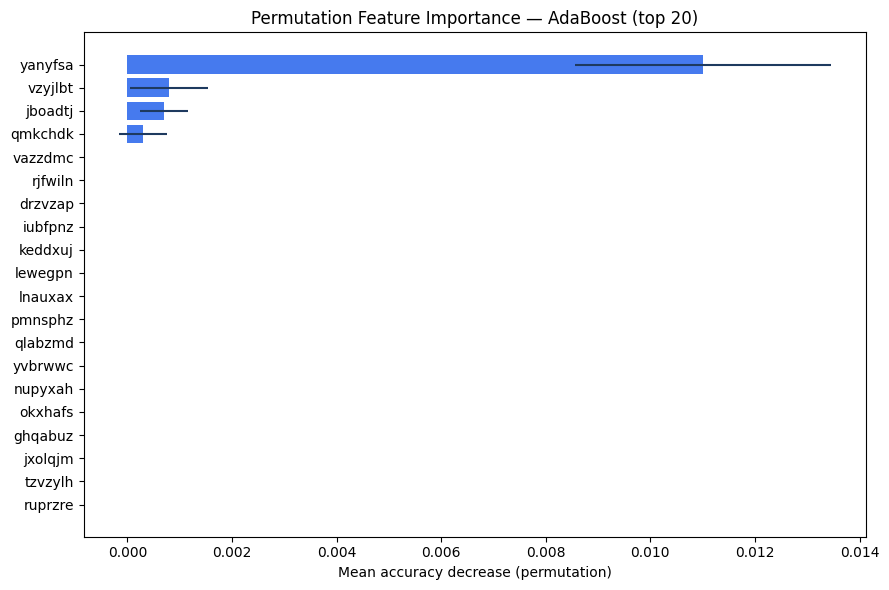

Plot guardado: adaboost_feature_importance.png


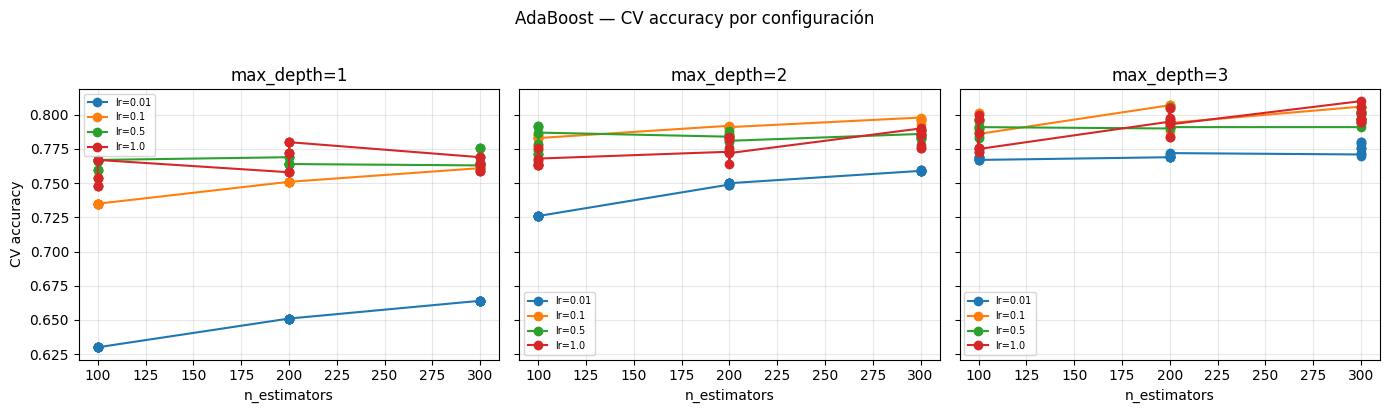

Plot guardado: adaboost_cv_curves.png


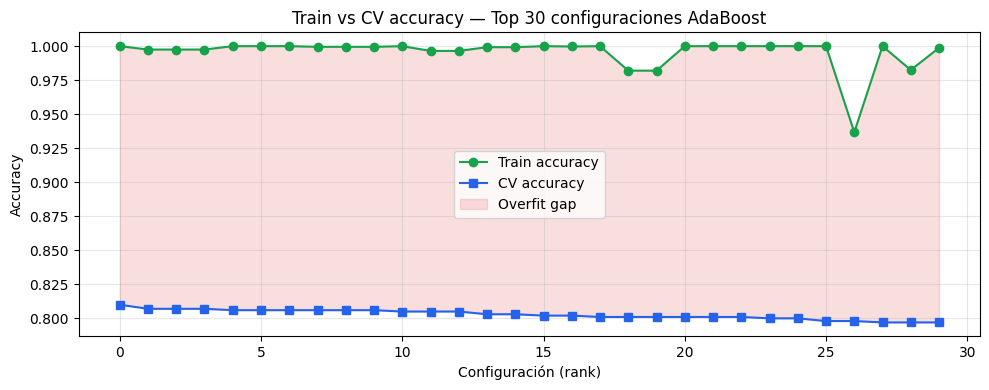

Plot guardado: adaboost_train_vs_cv.png


In [ ]:

fig, ax = plt.subplots(figsize=(9, 6))
top20 = importance_df.head(20)
ax.barh(
    top20["feature"][::-1],
    top20["importance"][::-1],
    xerr=top20["std"][::-1],
    color="#2563eb", alpha=0.85, ecolor="#1e3a5f"
)
ax.set_xlabel("Mean accuracy decrease (permutation)")
ax.set_title("Permutation Feature Importance — AdaBoost (top 20)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
plt.tight_layout()
plt.savefig("adaboost_feature_importance.png", dpi=150)
plt.show()
print("Plot guardado: adaboost_feature_importance.png")
 
#CV accuracy vs n_estimators por learning_rate
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, depth in zip(axes, [1, 2, 3]):
    subset = results_df[results_df["max_depth"] == depth]
    for lr, grp in subset.groupby("learning_rate"):
        grp_sorted = grp.sort_values("n_estimators")
        ax.plot(
            grp_sorted["n_estimators"],
            grp_sorted["cv_accuracy"],
            marker="o", label=f"lr={lr}"
        )
    ax.set_title(f"max_depth={depth}")
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("CV accuracy") if depth == 1 else None
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
fig.suptitle("AdaBoost — CV accuracy por configuración", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("adaboost_cv_curves.png", dpi=150)
plt.show()
print("Plot guardado: adaboost_cv_curves.png")
 
 
 
# Train vs CV accuracy (top 30 configs)
top30 = results_df.head(30)
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(top30))
ax.plot(x, top30["train_accuracy"], marker="o", label="Train accuracy", color="#16a34a")
ax.plot(x, top30["cv_accuracy"],    marker="s", label="CV accuracy",    color="#2563eb")
ax.fill_between(x, top30["cv_accuracy"], top30["train_accuracy"], alpha=0.15, color="#dc2626", label="Overfit gap")
ax.set_xlabel("Configuración (rank)")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs CV accuracy — Top 30 configuraciones AdaBoost")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("adaboost_train_vs_cv.png", dpi=150)
plt.show()
print("Plot guardado: adaboost_train_vs_cv.png")
 

Mejores parámetros

In [ ]:
best_params_clean = {
    k.replace("classifier__", "").replace("estimator__", "base__"):v
    for k, v in grid_search.best_params_.items()
}
 
print("\n Tabla")
print(f"Classifier        : AdaBoostClassifier")
print(f"Best parameters   : {best_params_clean}")
print(f"Train accuracy    : {train_acc:.4f}")
print(f"5-fold CV accuracy: {best_cv:.4f}")


 Tabla
Classifier        : AdaBoostClassifier
Best parameters   : {'base__max_depth': 3, 'base__min_samples_leaf': 1, 'base__min_samples_split': 2, 'learning_rate': 1.0, 'n_estimators': 300}
Train accuracy    : 1.0000
5-fold CV accuracy: 0.8100


## Bagging - Julio

In [ ]:
bagging_models = {
    "BG-01 Bagging baseline": {
        "model": BaggingClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "notes": "Configuracion por defecto (10 arboles sin restriccion)."
    },
    "BG-02 Bagging n_estimators=200": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Mas estimadores reducen la varianza del baseline."
    },
    "BG-03 Bagging + subespacio (max_features=0.5)": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=200,
            max_features=0.5,
            bootstrap_features=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Submuestreo de columnas: aprovecha la alta dimensionalidad decorrelando arboles."
    },
    "BG-04 Bagging shallow trees (max_depth=8)": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
            n_estimators=200,
            max_samples=0.8,
            max_features=0.5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Limita profundidad para reducir el sobreajuste del baseline."
    },
    "BG-05 Bagging + Scaler + PCA + LogReg": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
            ("classifier", BaggingClassifier(
                estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        "notes": "Bagging con estimador lineal sobre PCA; util si el problema es ~separable linealmente."
    },
    "BG-06 Bagging tuned": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=12, min_samples_leaf=2, random_state=RANDOM_STATE),
            n_estimators=300,
            max_samples=0.8,
            max_features=0.5,
            bootstrap_features=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Mejor combinacion: arboles moderadamente profundos + subespacio + 300 estimadores."
    }
}

# ============================================================
# Evaluacion
# ============================================================

bg_results = []
for name, config in bagging_models.items():
    evaluate_model(name=name, model=config["model"], notes=config["notes"])
    bg_results.append({
        "experiment": name,
        "train_accuracy": results[-1]["train_accuracy"],
        "cv_mean": results[-1]["cv_mean"],
        "cv_std": results[-1]["cv_std"],
        "notes": config["notes"]
    })

bg_results_df = (
    pd.DataFrame(bg_results)
    .sort_values("cv_mean", ascending=False)
    .reset_index(drop=True)
)
display(bg_results_df)

# ============================================================
# Mejor modelo entrenado con todo train
# ============================================================

best_bg_row = bg_results_df.iloc[0]
best_bg_name = best_bg_row["experiment"]
best_bg_model = bagging_models[best_bg_name]["model"]
best_bg_model.fit(X, y)

print("\nMejor modelo Bagging:", best_bg_name)
print(f"Train accuracy: {best_bg_row['train_accuracy']:.4f}")
print(f"5-fold CV accuracy: {best_bg_row['cv_mean']:.4f} (+/- {best_bg_row['cv_std']:.4f})")


Experimento: BG-01 Bagging baseline
Train accuracy: 0.9890
5-fold CV accuracy: 0.7730 (+/- 0.0240)
Notas: Configuracion por defecto (10 arboles sin restriccion).
Experimento: BG-02 Bagging n_estimators=200
Train accuracy: 1.0000
5-fold CV accuracy: 0.8110 (+/- 0.0169)
Notas: Mas estimadores reducen la varianza del baseline.
Experimento: BG-03 Bagging + subespacio (max_features=0.5)
Train accuracy: 1.0000
5-fold CV accuracy: 0.8190 (+/- 0.0188)
Notas: Submuestreo de columnas: aprovecha la alta dimensionalidad decorrelando arboles.
Experimento: BG-04 Bagging shallow trees (max_depth=8)
Train accuracy: 0.9940
5-fold CV accuracy: 0.8110 (+/- 0.0193)
Notas: Limita profundidad para reducir el sobreajuste del baseline.
Experimento: BG-05 Bagging + Scaler + PCA + LogReg
Train accuracy: 0.7900
5-fold CV accuracy: 0.6750 (+/- 0.0228)
Notas: Bagging con estimador lineal sobre PCA; util si el problema es ~separable linealmente.
Experimento: BG-06 Bagging tuned
Train accuracy: 0.9970
5-fold CV accu

,experiment,train_accuracy,cv_mean,cv_std,notes
0,BG-06 Bagging tuned,0.997,0.821,0.017436,Mejor combinacion: arboles moderadamente profu...
1,BG-03 Bagging + subespacio (max_features=0.5),1.000,0.819,0.018815,Submuestreo de columnas: aprovecha la alta dim...
2,BG-02 Bagging n_estimators=200,1.000,0.811,0.016852,Mas estimadores reducen la varianza del baseline.
3,BG-04 Bagging shallow trees (max_depth=8),0.994,0.811,0.019339,Limita profundidad para reducir el sobreajuste...
4,BG-01 Bagging baseline,0.989,0.773,0.024000,Configuracion por defecto (10 arboles sin rest...
5,BG-05 Bagging + Scaler + PCA + LogReg,0.790,0.675,0.022804,Bagging con estimador lineal sobre PCA; util s...



Mejor modelo Bagging: BG-06 Bagging tuned
Train accuracy: 0.9970
5-fold CV accuracy: 0.8210 (+/- 0.0174)


## Gradient Boosting - Julio

In [ ]:
gb_models = {
    "GB-01 GB baseline": {
        "model": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "notes": "Configuracion por defecto: n_estimators=100, lr=0.1, max_depth=3."
    },
    "GB-02 GB lr=0.05, n_estimators=300": {
        "model": GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            random_state=RANDOM_STATE
        ),
        "notes": "Reducimos learning_rate y compensamos con mas arboles para mejorar generalizacion."
    },
    "GB-03 GB stochastic subsample=0.8": {
        "model": GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            subsample=0.8, random_state=RANDOM_STATE
        ),
        "notes": "Stochastic GB: cada arbol ve el 80% de muestras → reduce varianza y sobreajuste."
    },
    "GB-04 GB deeper trees max_depth=5": {
        "model": GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=5,
            subsample=0.8, random_state=RANDOM_STATE
        ),
        "notes": "Arboles mas profundos capturan interacciones de mayor orden entre features."
    },
    "GB-05 GB + max_features=sqrt": {
        "model": GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            subsample=0.8, max_features="sqrt",
            random_state=RANDOM_STATE
        ),
        "notes": "Submuestreo de columnas (sqrt(609)≈25) para manejar la alta dimensionalidad."
    },
    "GB-06 GB + Scaler + PCA 100": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
            ("classifier", GradientBoostingClassifier(
                n_estimators=300, learning_rate=0.05, max_depth=3,
                subsample=0.8, random_state=RANDOM_STATE
            ))
        ]),
        "notes": "PCA para reducir ruido en un espacio de 609 dims antes del boosting."
    },
    "GB-07 GB tuned": {
        "model": GradientBoostingClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4,
            subsample=0.8, min_samples_leaf=5, max_features="sqrt",
            random_state=RANDOM_STATE
        ),
        "notes": "Mejor combinacion: lr bajo, mas arboles, profundidad moderada, regularizacion por hojas y submuestreo."
    }
}

# ============================================================
# Evaluacion
# ============================================================

gb_results_list = []
for name, config in gb_models.items():
    evaluate_model(name=name, model=config["model"], notes=config["notes"])
    gb_results_list.append({
        "experiment": name,
        "train_accuracy": results[-1]["train_accuracy"],
        "cv_mean": results[-1]["cv_mean"],
        "cv_std": results[-1]["cv_std"],
        "notes": config["notes"]
    })

gb_results_df = (
    pd.DataFrame(gb_results_list)
    .sort_values("cv_mean", ascending=False)
    .reset_index(drop=True)
)
display(gb_results_df)

# ============================================================
# Mejor modelo entrenado con todo train
# ============================================================

best_gb_row = gb_results_df.iloc[0]
best_gb_name = best_gb_row["experiment"]
best_gb_model = gb_models[best_gb_name]["model"]
best_gb_model.fit(X, y)

print("\nMejor modelo Gradient Boosting:", best_gb_name)
print(f"Train accuracy: {best_gb_row['train_accuracy']:.4f}")
print(f"5-fold CV accuracy: {best_gb_row['cv_mean']:.4f} (+/- {best_gb_row['cv_std']:.4f})")


Experimento: GB-01 GB baseline
Train accuracy: 1.0000
5-fold CV accuracy: 0.8020 (+/- 0.0229)
Notas: Configuracion por defecto: n_estimators=100, lr=0.1, max_depth=3.
Experimento: GB-02 GB lr=0.05, n_estimators=300
Train accuracy: 1.0000
5-fold CV accuracy: 0.8000 (+/- 0.0192)
Notas: Reducimos learning_rate y compensamos con mas arboles para mejorar generalizacion.
Experimento: GB-03 GB stochastic subsample=0.8
Train accuracy: 1.0000
5-fold CV accuracy: 0.8140 (+/- 0.0097)
Notas: Stochastic GB: cada arbol ve el 80% de muestras → reduce varianza y sobreajuste.
Experimento: GB-04 GB deeper trees max_depth=5
Train accuracy: 1.0000
5-fold CV accuracy: 0.8150 (+/- 0.0192)
Notas: Arboles mas profundos capturan interacciones de mayor orden entre features.
Experimento: GB-05 GB + max_features=sqrt
Train accuracy: 1.0000
5-fold CV accuracy: 0.8280 (+/- 0.0163)
Notas: Submuestreo de columnas (sqrt(609)≈25) para manejar la alta dimensionalidad.
Experimento: GB-06 GB + Scaler + PCA 100
Train accur

,experiment,train_accuracy,cv_mean,cv_std,notes
0,GB-05 GB + max_features=sqrt,1.000,0.828,0.016310,Submuestreo de columnas (sqrt(609)≈25) para ma...
1,GB-07 GB tuned,1.000,0.827,0.021354,"Mejor combinacion: lr bajo, mas arboles, profu..."
2,GB-04 GB deeper trees max_depth=5,1.000,0.815,0.019235,Arboles mas profundos capturan interacciones d...
3,GB-03 GB stochastic subsample=0.8,1.000,0.814,0.009695,Stochastic GB: cada arbol ve el 80% de muestra...
4,GB-06 GB + Scaler + PCA 100,0.999,0.805,0.025100,PCA para reducir ruido en un espacio de 609 di...
5,GB-01 GB baseline,1.000,0.802,0.022935,"Configuracion por defecto: n_estimators=100, l..."
6,"GB-02 GB lr=0.05, n_estimators=300",1.000,0.800,0.019235,Reducimos learning_rate y compensamos con mas ...



Mejor modelo Gradient Boosting: GB-05 GB + max_features=sqrt
Train accuracy: 1.0000
5-fold CV accuracy: 0.8280 (+/- 0.0163)


## Discriminant Analysis - Agostina

In [ ]:
# ============================================================
# Configuraciones probadas
# ============================================================

da_models = {
    "DA-01 LDA baseline": {
        "model": LinearDiscriminantAnalysis(),
        "notes": (
            "Baseline de LDA sin regularización. "
            "Usa una matriz de covarianza compartida entre clases."
        )
    },

    "DA-02 LDA shrinkage=auto": {
        "model": LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto"
        ),
        "notes": (
            "LDA con regularización automática de la matriz de covarianza. "
            "Se prueba porque el dataset tiene alta dimensionalidad."
        )
    },

    "DA-03 LDA shrinkage=0.8": {
        "model": LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage=0.8
        ),
        "notes": (
            "LDA con shrinkage fijo. "
            "Representa la mejor configuración aproximada sin escalado previo."
        )
    },

    "DA-04 QDA baseline": {
        "model": QuadraticDiscriminantAnalysis(),
        "notes": (
            "QDA sin regularización. "
            "Estima una matriz de covarianza por clase, por lo que puede ser inestable "
            "cuando hay muchas variables."
        )
    },

    "DA-05 QDA reg_param=0.3": {
        "model": QuadraticDiscriminantAnalysis(
            reg_param=0.3
        ),
        "notes": (
            "QDA con regularización de covarianza mediante reg_param. "
            "Se prueba para reducir el sobreajuste del QDA baseline."
        )
    },

    "DA-06 StandardScaler + LDA shrinkage=1.0": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=1.0
            ))
        ]),
        "notes": (
            "LDA con escalado previo y regularización máxima. "
            "Aproxima una covarianza muy restringida."
        )
    },

    "DA-07 StandardScaler + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "LDA con escalado previo y shrinkage alto. "
            "Mejor configuración encontrada sin PCA."
        )
    },

    "DA-08 StandardScaler + PCA 50 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Reducción de dimensionalidad a 50 componentes antes de LDA regularizado."
        )
    },

    "DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Mejor configuración encontrada para Discriminant Analysis: "
            "escalado, reducción de dimensionalidad a 100 componentes y LDA regularizado."
        )
    },

    "DA-10 StandardScaler + PCA 150 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=150, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Reducción de dimensionalidad a 150 componentes antes de LDA regularizado."
        )
    },

    "DA-11 StandardScaler + PCA 300 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=300, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Reducción de dimensionalidad a 300 componentes antes de LDA regularizado."
        )
    }
}

In [ ]:
# ============================================================
# Evaluación
# ============================================================

da_results = []

for name, config in da_models.items():
    model, scores = evaluate_model(
        name=name,
        model=config["model"],
        notes=config["notes"]
    )

    da_results.append({
        "experiment": name,
        "train_accuracy": results[-1]["train_accuracy"],
        "cv_mean": results[-1]["cv_mean"],
        "cv_std": results[-1]["cv_std"],
        "notes": config["notes"]
    })

In [ ]:
# ============================================================
# Tabla comparativa
# ============================================================

da_results_df = (
    pd.DataFrame(da_results)
    .sort_values("cv_mean", ascending=False)
    .reset_index(drop=True)
)

da_results_df

,experiment,train_accuracy,cv_mean,cv_std,notes
0,DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975,0.769,0.738,0.019391,"Mejor configuración encontrada para Discriminant Analysis: escalado, reducción de dimensionalidad a 100 componentes ..."
1,DA-10 StandardScaler + PCA 150 + LDA shrinkage=0.975,0.785,0.728,0.022494,Reducción de dimensionalidad a 150 componentes antes de LDA regularizado.
2,DA-08 StandardScaler + PCA 50 + LDA shrinkage=0.975,0.754,0.725,0.007071,Reducción de dimensionalidad a 50 componentes antes de LDA regularizado.
3,DA-11 StandardScaler + PCA 300 + LDA shrinkage=0.975,0.808,0.722,0.026944,Reducción de dimensionalidad a 300 componentes antes de LDA regularizado.
4,DA-07 StandardScaler + LDA shrinkage=0.975,0.834,0.721,0.016248,LDA con escalado previo y shrinkage alto. Mejor configuración encontrada sin PCA.
5,DA-06 StandardScaler + LDA shrinkage=1.0,0.801,0.705,0.011402,LDA con escalado previo y regularización máxima. Aproxima una covarianza muy restringida.
6,DA-03 LDA shrinkage=0.8,0.800,0.614,0.025962,LDA con shrinkage fijo. Representa la mejor configuración aproximada sin escalado previo.
7,DA-02 LDA shrinkage=auto,0.899,0.596,0.020591,LDA con regularización automática de la matriz de covarianza. Se prueba porque el dataset tiene alta dimensionalidad.
8,DA-01 LDA baseline,0.953,0.399,0.023108,Baseline de LDA sin regularización. Usa una matriz de covarianza compartida entre clases.
9,DA-05 QDA reg_param=0.3,1.000,0.350,0.031305,QDA con regularización de covarianza mediante reg_param. Se prueba para reducir el sobreajuste del QDA baseline.


In [ ]:
# ============================================================
# Mejor configuración
# ============================================================

best_da_row = da_results_df.iloc[0]

print("Mejor modelo de Discriminant Analysis")
print("------------------------------------")
print("Experimento:", best_da_row["experiment"])
print(f"Train accuracy: {best_da_row['train_accuracy']:.4f}")
print(f"5-fold CV accuracy: {best_da_row['cv_mean']:.4f} (+/- {best_da_row['cv_std']:.4f})")
print("Notas:", best_da_row["notes"])

Mejor modelo de Discriminant Analysis
------------------------------------
Experimento: DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975
Train accuracy: 0.7690
5-fold CV accuracy: 0.7380 (+/- 0.0194)
Notas: Mejor configuración encontrada para Discriminant Analysis: escalado, reducción de dimensionalidad a 100 componentes y LDA regularizado.


In [ ]:
# ============================================================
# Entrenamos al mejor modelo con todo train
# ============================================================

best_da_name = best_da_row["experiment"]
best_da_model = da_models[best_da_name]["model"]

best_da_model.fit(X, y)

print("Modelo DA final entrenado:")
print(best_da_name)

Modelo DA final entrenado:
DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975


## Stacking - Lama

In [ ]:
# codigo lama